# ⚙️ Neural Network Hyperparameter Tuning

## Overview
This notebook contains a deep learning exercise completed during the AI Bootcamp. The project explores how different hyperparameters affect the performance of a fully connected neural network on a multi-class image classification task.

## Objective
The objective of this exercise is to improve model performance by experimenting with network architecture, optimization settings, and training parameters.

## Skills Practiced

- Hyperparameter Tuning
- Neural Network Optimization
- Multi-class Classification
- Model Evaluation
- Keras

---
**Tools:** Python, NumPy, TensorFlow, Keras

In [1]:
from scipy import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
from keras.optimizers import SGD, Adam, RMSprop
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score

C:\Users\MY-PC\AppData\Roaming\Python\Python312\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
data = io.loadmat('hoda.mat')
data


{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Thu Jun 30 20:26:30 2011',
 '__version__': '1.0',
 '__globals__': [],
 'Data': array([[array([[  0,   0,   0,   0, 255, 255,   0,   0,   0,   0,   0,   0,   0,
                   0,   0,   0,   0,   0,   0,   0],
                [  0,   0,   0, 255, 255, 255, 255,   0,   0,   0,   0,   0,   0,
                   0,   0,   0,   0,   0,   0,   0],
                [  0,   0, 255, 255, 255, 255, 255,   0,   0,   0,   0,   0,   0,
                   0,   0,   0,   0, 255, 255,   0],
                [  0, 255, 255, 255, 255, 255,   0,   0,   0,   0,   0,   0,   0,
                   0,   0,   0, 255, 255, 255, 255],
                [  0, 255, 255, 255, 255,   0,   0,   0,   0,   0,   0,   0,   0,
                   0,   0, 255, 255, 255, 255,   0],
                [  0, 255, 255, 255,   0,   0,   0,   0,   0,   0,   0,   0,   0,
                   0, 255, 255, 255, 255, 255,   0],
                [255, 255, 255, 255,   0,  

In [3]:
data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'Data', 'labels'])

In [4]:
X = np.squeeze(data['Data'])
y = np.squeeze(data['labels'])

X_train = X[:40000]
y_train = y[:40000]

X_valid = X[40000:50000]
y_valid = y[40000:50000]

X_test = X[50000:60000]
y_test = y[50000:60000]

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)


(40000,) (40000,)
(10000,) (10000,)
(10000,) (10000,)


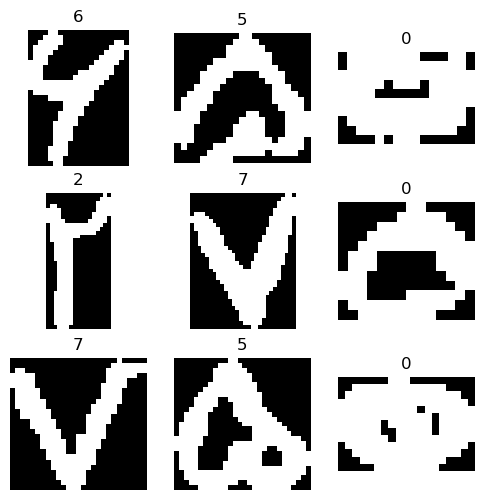

In [6]:
# plot the first 9 images in the training set in a 3x3 grid
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()


In [7]:
def resize_to_62(img):
    h, w = img.shape
    padded = np.zeros((62, 62))
    start_h = (62 - h) // 2
    start_w = (62 - w) // 2
    padded[start_h:start_h+h, start_w:start_w+w] = img
    return padded

X_train_resized = np.array([resize_to_62(img) for img in X_train])
X_valid_resized = np.array([resize_to_62(img) for img in X_valid])
X_test_resized  = np.array([resize_to_62(img) for img in X_test])


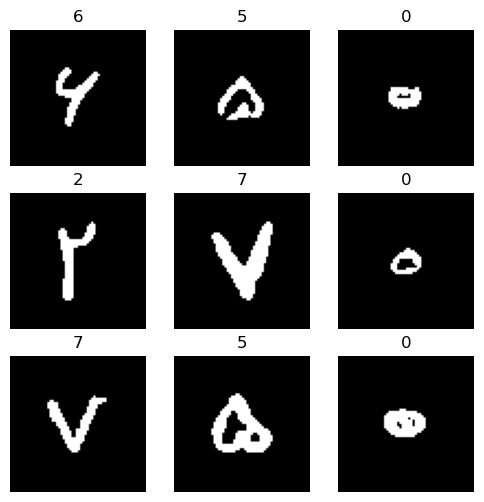

In [8]:
# plot the first 9 images in the training set in a 3x3 grid after resizing
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train_resized[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()


In [9]:
X_train_vectorized = X_train_resized.reshape(X_train_resized.shape[0], -1)
X_valid_vectorized = X_valid_resized.reshape(X_valid_resized.shape[0], -1)
X_test_vectorized  = X_test_resized.reshape(X_test_resized.shape[0], -1)

print(X_train_vectorized.shape)
print(X_valid_vectorized.shape)
print(X_test_vectorized.shape)


(40000, 3844)
(10000, 3844)
(10000, 3844)


In [10]:
X_train_normalized = X_train_vectorized / 255.0
X_valid_normalized = X_valid_vectorized / 255.0
X_test_normalized  = X_test_vectorized / 255.0


In [11]:
y_train_onehot = to_categorical(y_train, num_classes=10)
y_valid_onehot = to_categorical(y_valid, num_classes=10)
y_test_onehot  = to_categorical(y_test, num_classes=10)

print(y_train_onehot.shape)
print(y_valid_onehot.shape)
print(y_test_onehot.shape)


(40000, 10)
(10000, 10)
(10000, 10)


In [12]:
model1 = Sequential()
model1.add(Dense(64, activation='tanh', input_shape=(3844,)))
model1.add(Dense(10, activation='softmax'))


C:\Users\MY-PC\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model1.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


In [14]:
history1 = model1.fit(
    X_train_normalized,
    y_train_onehot,
    validation_data=(X_valid_normalized, y_valid_onehot),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8932 - loss: 0.4456 - val_accuracy: 0.9247 - val_loss: 0.2751
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9370 - loss: 0.2371 - val_accuracy: 0.9387 - val_loss: 0.2179
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9477 - loss: 0.1970 - val_accuracy: 0.9479 - val_loss: 0.1916
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9549 - loss: 0.1743 - val_accuracy: 0.9545 - val_loss: 0.1743
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9592 - loss: 0.1581 - val_accuracy: 0.9571 - val_loss: 0.1617
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9624 - loss: 0.1457 - val_accuracy: 0.9602 - val_loss: 0.1528
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9644 - loss: 0.1358 - val_accuracy: 0.9626 - val_loss: 0.1443
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9671 - loss: 0

In [15]:
# To-Do (Final accuracy on validation data)
val_loss, val_acc = model1.evaluate(X_valid_normalized, y_valid_onehot, verbose=0)
print(val_acc)


0.9796000123023987


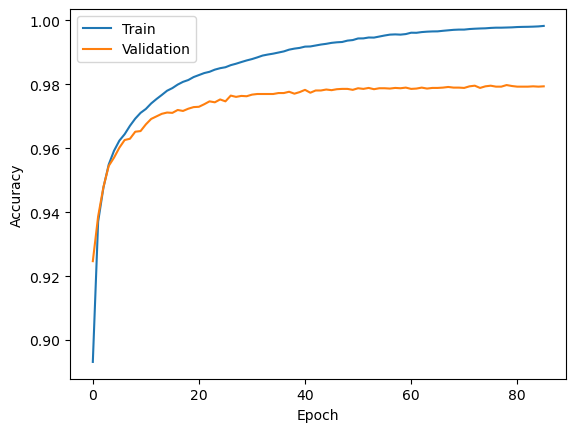

In [16]:
# To-Do (Plot training and validation accuracy)
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


In [17]:
model2 = Sequential()
model2.add(Dense(64, activation='relu', input_shape=(3844,)))
model2.add(Dense(10, activation='softmax'))


In [18]:
model2.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


In [19]:
history2 = model2.fit(
    X_train_normalized,
    y_train_onehot,
    validation_data=(X_valid_normalized, y_valid_onehot),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8903 - loss: 0.4440 - val_accuracy: 0.9305 - val_loss: 0.2540
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9415 - loss: 0.2206 - val_accuracy: 0.9428 - val_loss: 0.2084
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9512 - loss: 0.1869 - val_accuracy: 0.9490 - val_loss: 0.1854
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9567 - loss: 0.1665 - val_accuracy: 0.9521 - val_loss: 0.1722
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9606 - loss: 0.1516 - val_accuracy: 0.9570 - val_loss: 0.1596
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9642 - loss: 0.1395 - val_accuracy: 0.9592 - val_loss: 0.1498
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9669 - loss: 0.1292 - val_accuracy: 0.9600 - val_loss: 0.1430
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9689 - loss: 0

In [20]:
# To-Do (Final accuracy on validation data)
val_loss2, val_acc2 = model2.evaluate(X_valid_normalized, y_valid_onehot, verbose=0)
print(val_acc2)


0.9796000123023987


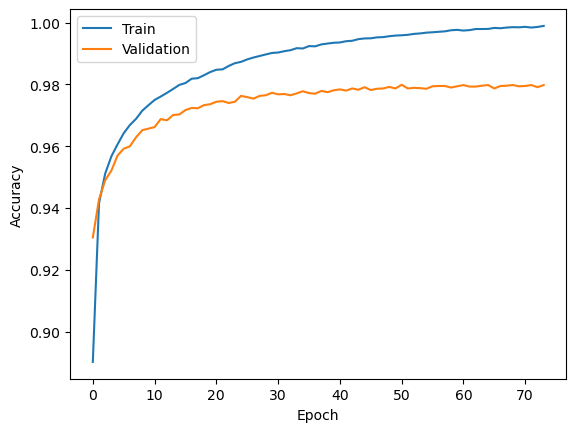

In [21]:
# To-Do (Plot training and validation accuracy)
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


In [22]:
model3 = Sequential()
model3.add(Dense(64, activation='relu', input_shape=(3844,)))
model3.add(Dense(256, activation='relu'))
model3.add(Dense(10, activation='softmax'))


In [23]:
model3.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


In [24]:
history3 = model3.fit(
    X_train_normalized,
    y_train_onehot,
    validation_data=(X_valid_normalized, y_valid_onehot),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8678 - loss: 0.5409 - val_accuracy: 0.9304 - val_loss: 0.2455
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9441 - loss: 0.2065 - val_accuracy: 0.9466 - val_loss: 0.1875
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9543 - loss: 0.1690 - val_accuracy: 0.9537 - val_loss: 0.1655
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9611 - loss: 0.1463 - val_accuracy: 0.9595 - val_loss: 0.1467
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9659 - loss: 0.1294 - val_accuracy: 0.9616 - val_loss: 0.1375
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9696 - loss: 0.1160 - val_accuracy: 0.9649 - val_loss: 0.1261
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9721 - loss: 0.1051 - val_accuracy: 0.9656 - val_loss: 0.1237
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9755 - loss: 0

In [25]:
val_loss3, val_acc3 = model3.evaluate(X_valid_normalized, y_valid_onehot, verbose=0)
print(val_acc3)


0.9810000061988831


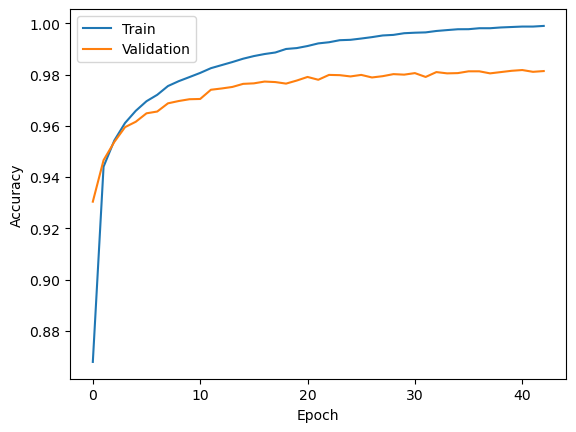

In [26]:
plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


In [27]:
from keras.layers import LeakyReLU

model4 = Sequential()
model4.add(Dense(64, input_shape=(3844,)))
model4.add(LeakyReLU(alpha=0.1))
model4.add(Dense(256))
model4.add(LeakyReLU(alpha=0.1))
model4.add(Dense(10, activation='softmax'))


C:\Users\MY-PC\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [28]:
model4.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


In [29]:
history4 = model4.fit(
    X_train_normalized,
    y_train_onehot,
    validation_data=(X_valid_normalized, y_valid_onehot),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8676 - loss: 0.5587 - val_accuracy: 0.9333 - val_loss: 0.2415
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9430 - loss: 0.2071 - val_accuracy: 0.9475 - val_loss: 0.1890
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9552 - loss: 0.1718 - val_accuracy: 0.9524 - val_loss: 0.1705
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9599 - loss: 0.1513 - val_accuracy: 0.9580 - val_loss: 0.1519
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9639 - loss: 0.1356 - val_accuracy: 0.9616 - val_loss: 0.1399
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9682 - loss: 0.1229 - val_accuracy: 0.9652 - val_loss: 0.1306
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9707 - loss: 0.1119 - val_accuracy: 0.9661 - val_loss: 0.1271
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9728 - loss: 0

In [30]:
val_loss4, val_acc4 = model4.evaluate(X_valid_normalized, y_valid_onehot, verbose=0)
print(val_acc4)


0.9804999828338623


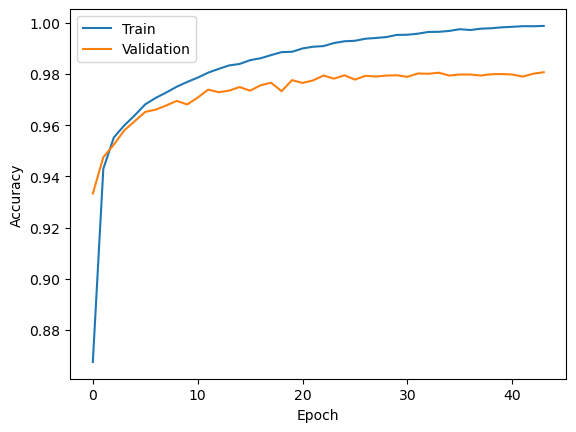

In [31]:
plt.plot(history4.history['accuracy'])
plt.plot(history4.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


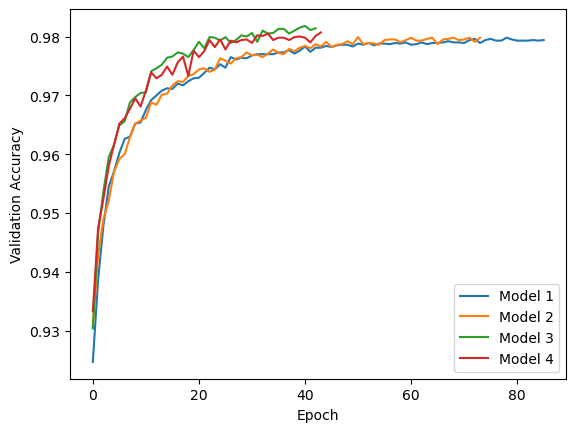

In [32]:
# To-Do (Plot validation accuracy of all models)
plt.plot(history1.history['val_accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.plot(history3.history['val_accuracy'])
plt.plot(history4.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(['Model 1', 'Model 2', 'Model 3', 'Model 4'])
plt.show()


Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9317 - loss: 0.2282 - val_accuracy: 0.9769 - val_loss: 0.0830
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9706 - loss: 0.1002 - val_accuracy: 0.9781 - val_loss: 0.0768
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9747 - loss: 0.0810 - val_accuracy: 0.9799 - val_loss: 0.0768
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9797 - loss: 0.0663 - val_accuracy: 0.9820 - val_loss: 0.0690
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9819 - loss: 0.0585 - val_accuracy: 0.9812 - val_loss: 0.0720
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9827 - loss: 0.0552 - val_accuracy: 0.9845 - val_loss: 0.0667
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9847 - loss: 0.0491 - val_accuracy: 0.9818 - val_loss: 0.0696
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9860 - loss: 0

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │       492,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,583,264 (6.04 MB)

 Trainable params: 527,754 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,055,510 (4.03 MB)

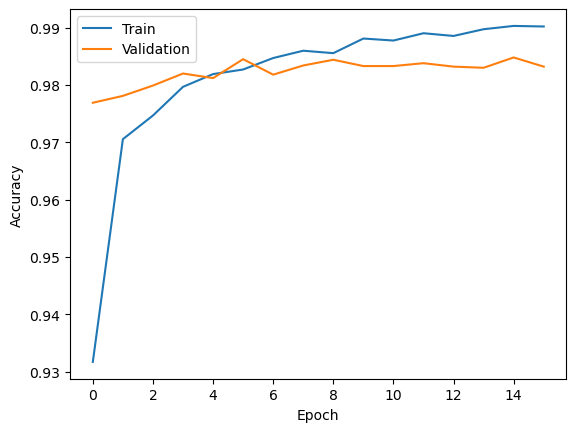

In [33]:
# To-Do (Further tuning of hyperparameters)
model_final = Sequential()
model_final.add(Dense(128, activation='relu', input_shape=(3844,)))
model_final.add(Dropout(0.3))
model_final.add(Dense(256, activation='relu'))
model_final.add(Dropout(0.3))
model_final.add(Dense(10, activation='softmax'))

model_final.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_final = model_final.fit(
    X_train_normalized,
    y_train_onehot,
    validation_data=(X_valid_normalized, y_valid_onehot),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)

model_final.summary()

plt.plot(history_final.history['accuracy'])
plt.plot(history_final.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


In [34]:
# To-Do (Final metrics on testing data)
y_pred = np.argmax(model_final.predict(X_test_normalized), axis=1)
y_true = y_test

print(classification_report(y_true, y_pred))


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       975
           1       0.98      0.99      0.99       999
           2       0.98      0.98      0.98       992
           3       0.98      0.97      0.97      1005
           4       0.97      0.98      0.97       991
           5       0.98      0.99      0.99      1020
           6       0.98      0.97      0.98       992
           7       0.99      0.99      0.99      1006
           8       0.99      1.00      0.99      1024
           9       0.99      0.98      0.98       996

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

